# Import Libraries

In [1]:
# =======================
# Standard library
# =======================
import os
import math
import random
from collections import defaultdict
from types import SimpleNamespace

# =======================
# Scientific stack
# =======================
import numpy as np
import pandas as pd
import networkx as nx
from scipy.interpolate import griddata
from scipy.ndimage import gaussian_filter
from scipy.spatial import cKDTree
from skimage.measure import label

# =======================
# Geospatial stack
# =======================
import geopandas as gpd
import rasterio
from rasterio.features import rasterize
from rasterio.mask import mask
from rasterio.transform import from_origin

import osmnx as ox
from pyproj import CRS, Transformer

from shapely.errors import TopologicalError
from shapely.geometry import (
    Point,
    LineString,
    MultiLineString,
    Polygon,
    MultiPolygon,
    box,
)
from shapely.ops import unary_union, linemerge
from shapely.strtree import STRtree

# Shapely version compatibility (make_valid exists in Shapely ≥ 2.0)
try:
    from shapely.validation import make_valid
except Exception:
    make_valid = None

# =======================
# Plotting
# =======================
import matplotlib.pyplot as plt
from matplotlib import cm, colors
from matplotlib.colors import LightSource

# =======================
# Time-series / NetCDF
# =======================
import xarray as xr

import sys
from pathlib import Path

SEWERTRIS_DIR = Path("..") / "Functions"   # adjust if needed
sys.path.append(str(SEWERTRIS_DIR))

# =======================
# SewerTris modules (your split files)
# =======================
import sewertris_fn_0_1 as SewerTris
import sewertris_plots_0_1 as plots
import sewertris_swmm_0_1 as swmm

# =======================
# Optional: reload during development
# =======================
import importlib
importlib.reload(SewerTris)
importlib.reload(plots)
importlib.reload(swmm)

<module 'sewertris_swmm_0_1' from '/Users/kevinblanco/Documents/Sewertris/Examples/../Functions/sewertris_swmm_0_1.py'>

## 1. Define the Mask

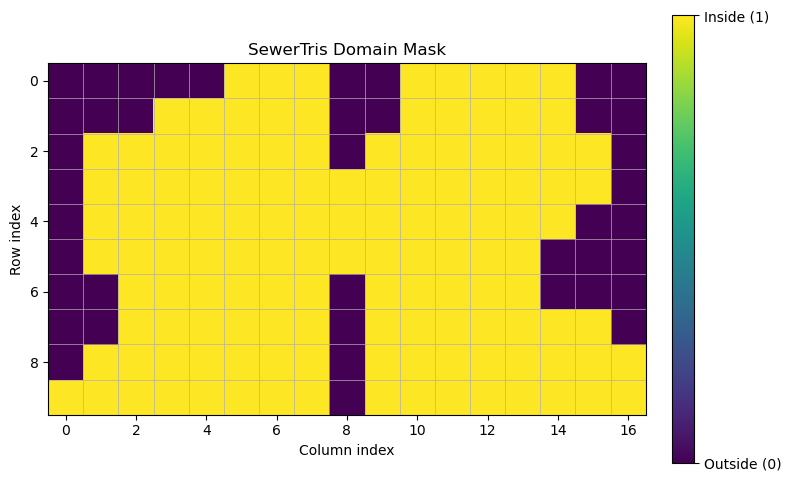

In [2]:
# --- Parameters ---
min_width = 100  # meters
use_shapefile = False  # Set to False to use manual domain_mask
if use_shapefile:
    # Read shapefile (assumed WGS84)
    gdf = gpd.read_file(shapefile_path)
    gdf = gdf.to_crs("EPSG:4326")
    # Get bounds in WGS84
    minx, miny, maxx, maxy = gdf.total_bounds
    # Project to UTM for metric calculations
    utm_crs = gdf.estimate_utm_crs()
    gdf_utm = gdf.to_crs(utm_crs)
    minx_utm, miny_utm, maxx_utm, maxy_utm = gdf_utm.total_bounds
    width_m = maxx_utm - minx_utm
    height_m = maxy_utm - miny_utm
    n_cols = int(np.ceil(width_m / min_width))
    n_rows = int(np.ceil(height_m / min_width))
    # Create grid in UTM
    x_edges = np.linspace(minx_utm, maxx_utm, n_cols+1)
    y_edges = np.linspace(miny_utm, maxy_utm, n_rows+1)
    # Prepare transformer for grid cell centers
    transformer = Transformer.from_crs(utm_crs, "EPSG:4326", always_xy=True)
    domain_mask = np.zeros((n_rows, n_cols), dtype=int)
    for i in range(n_rows):
        for j in range(n_cols):
            # Cell center in UTM
            cx = 0.5 * (x_edges[j] + x_edges[j+1])
            cy = 0.5 * (y_edges[i] + y_edges[i+1])
            # Transform to WGS84
            lon, lat = transformer.transform(cx, cy)
            pt = gpd.points_from_xy([lon], [lat], crs="EPSG:4326")[0]
            # Check if inside basin
            if gdf.contains(pt).any():
                domain_mask[i, j] = 1
else:
    # Manual domain_mask definition (as before)
    # Example: Top wide rectangle, bottom extra-large L
    # 1 = inside domain, 0 = outside

    domain_mask = np.array([
        [0,0,0,0,0,1,1,1,0,0,1,1,1,1,1,0,0],
        [0,0,0,1,1,1,1,1,0,0,1,1,1,1,1,0,0],
        [0,1,1,1,1,1,1,1,0,1,1,1,1,1,1,1,0],
        [0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0],
        [0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0],
        [0,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,0],
        [0,0,1,1,1,1,1,1,0,1,1,1,1,1,0,0,0],
        [0,0,1,1,1,1,1,1,0,1,1,1,1,1,1,1,0],
        [0,1,1,1,1,1,1,1,0,1,1,1,1,1,1,1,1],
        [1,1,1,1,1,1,1,1,0,1,1,1,1,1,1,1,1],
    ])

plots.plot_domain_mask(domain_mask, title="SewerTris Domain Mask")

## 2. Defining Default Parameter (Create the System)

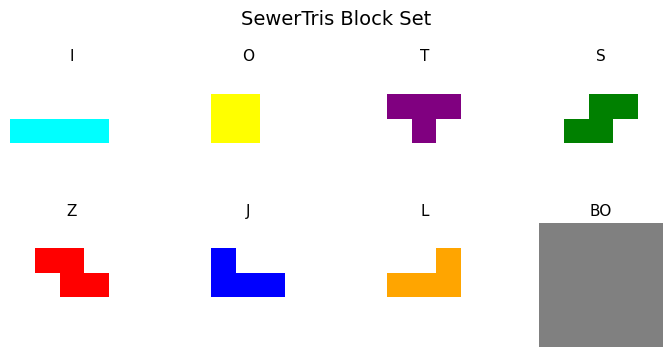

In [3]:
# Tetromino definitions (all rotations)
tetrominoes = {
    'I': [np.array([[1,1,1,1]]), np.array([[1],[1],[1],[1]])],
    'O': [np.array([[1,1],[1,1]])],
    'T': [np.array([[1,1,1],[0,1,0]]), np.array([[0,1],[1,1],[0,1]]), np.array([[0,1,0],[1,1,1]]), np.array([[1,0],[1,1],[1,0]])],
    'S': [np.array([[0,1,1],[1,1,0]]), np.array([[1,0],[1,1],[0,1]])],
    'Z': [np.array([[1,1,0],[0,1,1]]), np.array([[0,1],[1,1],[1,0]])],
    'J': [np.array([[1,0,0],[1,1,1]]), np.array([[1,1],[1,0],[1,0]]), np.array([[1,1,1],[0,0,1]]), np.array([[0,1],[0,1],[1,1]])],
    'L': [np.array([[0,0,1],[1,1,1]]), np.array([[1,0],[1,0],[1,1]]), np.array([[1,1,1],[1,0,0]]), np.array([[1,1],[0,1],[0,1]])],
    'BO': [np.array([[1,1,1,1,1],[1,1,1,1,1],[1,1,1,1,1],[1,1,1,1,1],[1,1,1,1,1]])],
}

# Assign a color to each tetromino
tetromino_colors = {
    'I': 'cyan',
    'O': 'yellow',
    'T': 'purple',
    'S': 'green',
    'Z': 'red',
    'J': 'blue',
    'L': 'orange',
    'BO': 'grey',
}

plots.plot_tetromino_set(tetrominoes, tetromino_colors, ncols=4)

Total blocks: 58
✅ Exported 57 figures to output_sewertris_1/City_1.shp


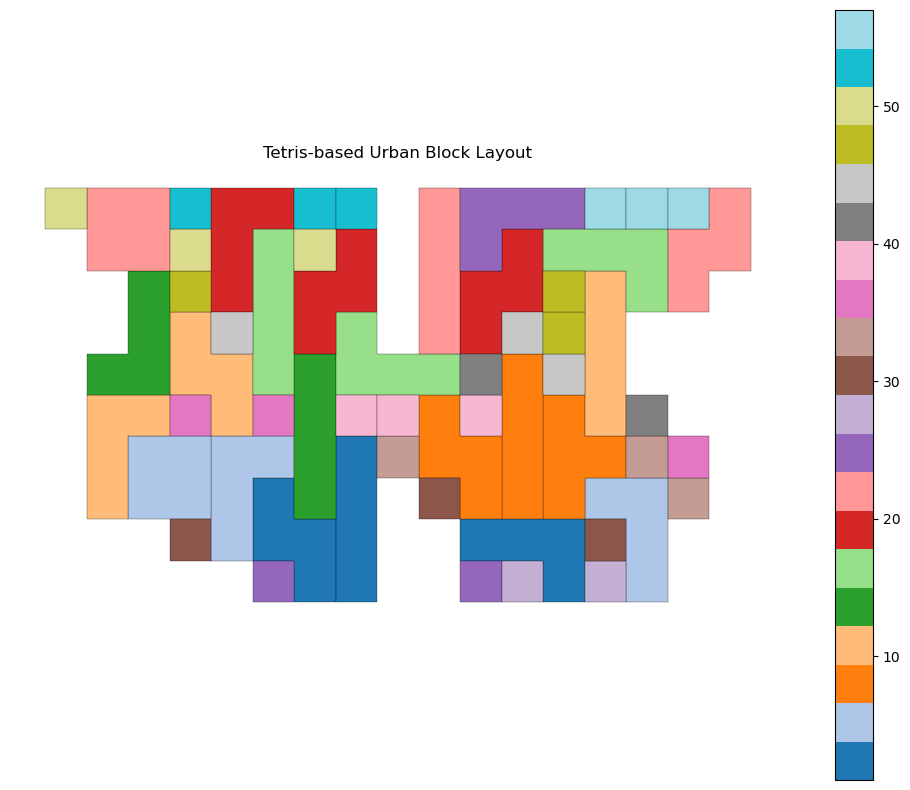

In [4]:
# Fill the domain with tetrominoes and blocks
filled_board, id_type_map, block_id = SewerTris.fill_domain_with_tetrominoes_and_blocks(domain_mask, tetrominoes)
print("Total blocks:", len(np.unique(filled_board)))
# Export the filled board to a shapefile
output_folder = "output_sewertris_1"
os.makedirs(output_folder, exist_ok=True)  # Create if it doesn't exist
output_shapefile = os.path.join(output_folder, "City_1.shp")
cell_size_meters = min_width  # Cell size in meters
SewerTris.export_individual_figures_to_shapefile(
    filled_board=filled_board,
    cell_size=cell_size_meters,
    output_path=output_shapefile,
    id_to_type_map=id_type_map,
    crs="EPSG:3857",
    flip_y=True  # Set to True if you want to flip Y-axis (N/S orientation) --- IGNORE ---
)
plots.plot_filled_board_shapefile(output_shapefile)

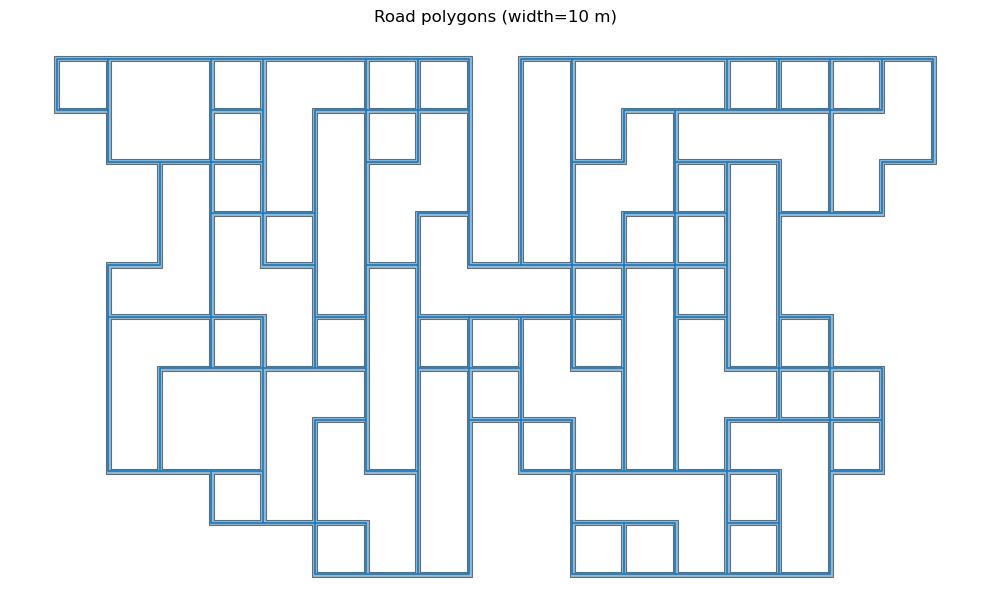

In [5]:
# Generate road network from blocks
road_width = 10  # Width of the road in meters
road_lines, road_buffer, crs = SewerTris.generate_road_network_from_blocks(
    blocks_path=output_shapefile,
    road_width=road_width,          # road width in meters
    simplify_tol=0.5       # optional geometry simplification
)
gpd.GeoDataFrame(geometry=[road_lines], crs=crs).to_file(os.path.join(output_folder,"road_centerlines.shp"))
gpd.GeoDataFrame(geometry=[road_buffer], crs=crs).to_file(os.path.join(output_folder,"road_polygons.shp"))

plots.plot_roads(
    road_lines=road_lines,
    road_buffer=road_buffer,
    crs=crs,
    title=f"Road polygons (width={road_width} m)",
)

[OK] Boundary lines written to: output_sewertris_1/road_boundary_lines.shp
[OK] Outer shell polygon(s) written to: output_sewertris_1/road_outer_shell.shp
Original boundary CRS: EPSG:3857
Original roads CRS: EPSG:3857

Boundary extent:
X range: -5.00 to 1705.00
Y range: -5.00 to 1005.00
Boundary CRS: EPSG:3857
Boundary bounds: [  -5.   -5. 1705. 1005.]
Grid shape: (122, 192)
Grid extent:
  X: -110.00 to 1810.00
  Y: -110.00 to 1110.00
Creating mask...
Processing row 0 of 122
Processing row 100 of 122
Outlet cell: (57, 20)
Computing geodesic distances...
Processing roads...


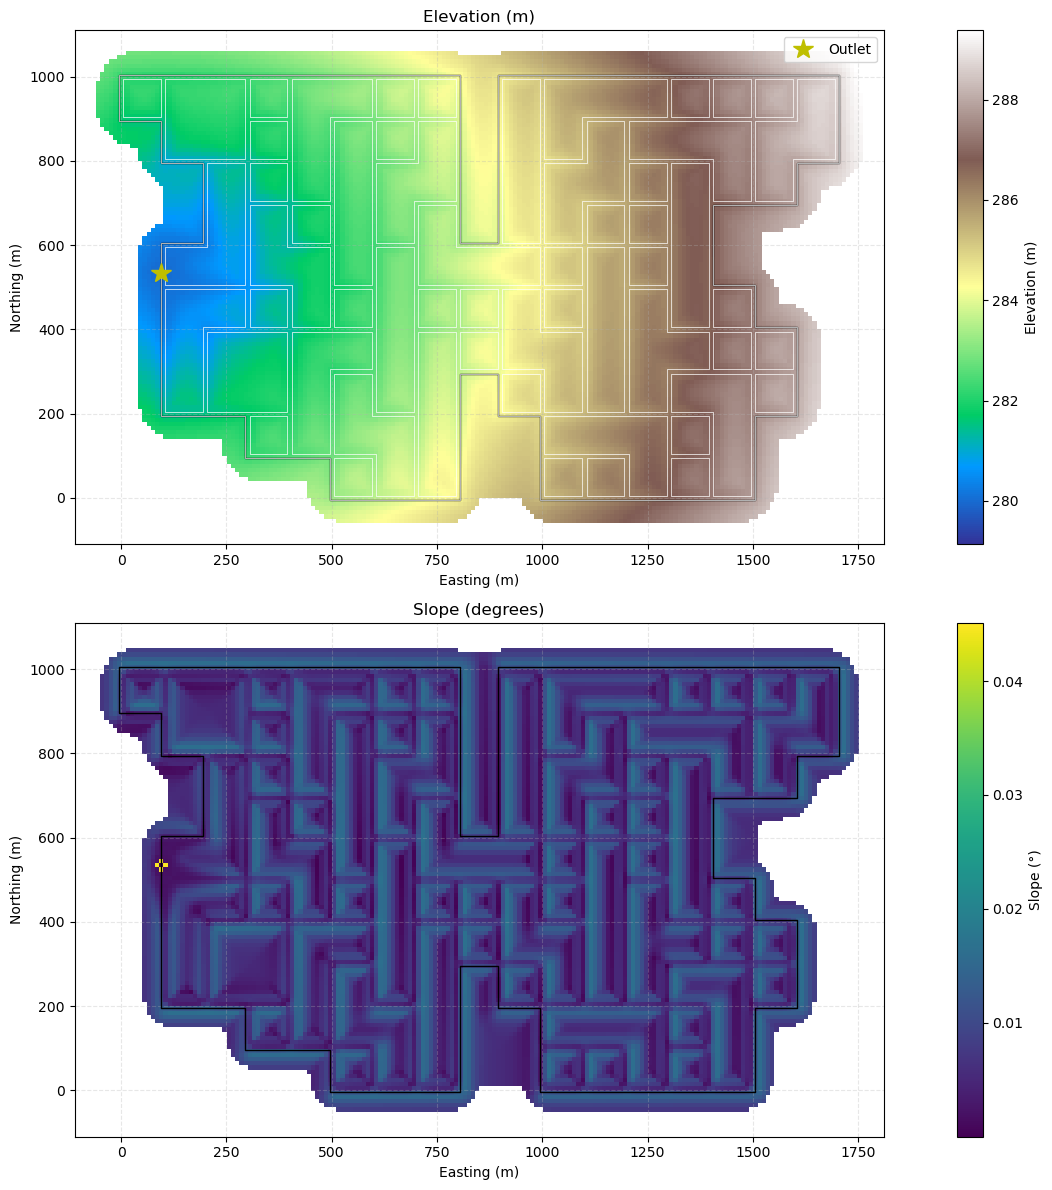


Terrain Statistics:
Elevation range: 279.14m - 289.38m
Mean elevation: 284.42m
Mean slope: 0.01°
Max slope: 0.05°

Drainage Statistics:
Points with proper drainage: 17281.0 out of 19926 (86.7%)
Using CRS: EPSG:3857
Topography successfully generated and saved to output_sewertris_1/generated_topography.tif
DEM resolution: 10m
Elevation range: 280m - 290m
Output CRS: EPSG:3857
Grid extent: 
  X: -110.00 to 1810.00
  Y: 1110.00 to -110.00


In [6]:
# Extract road boundaries
roads_path = os.path.join(output_folder,"road_polygons.shp")
SewerTris.extract_boundary(
    roads_path,
    out_boundary_lines=os.path.join(output_folder,"road_boundary_lines.shp"),          # lines (outer +/- holes)
    out_outer_shell_polygon=os.path.join(output_folder,"road_outer_shell.shp"),        # polygon(s) with holes removed
    keep_holes=False                                       # only outer rings in the line output
)

# Generate topography
config = SewerTris.TopographyConfig(
    min_elevation=280,    # meters
    max_elevation=290,    # meters
    cell_size=10,         # meters - reduced for better resolution
    outlet_direction='W', # North (N), South (S), East (E), or West (W)
    smoothing_factor=1  # Reduced for sharper drainage patterns
)

# File paths for Stillwater data
boundary_path = os.path.join(output_folder,"road_outer_shell.shp")
roads_path = os.path.join(output_folder,"road_polygons.shp")

# Ensure input files exist
if not os.path.exists(boundary_path) or not os.path.exists(roads_path):
    raise FileNotFoundError("Input shapefiles not found. Please check the file paths.")

try:
    # Generate topography
    elevation, xx, yy, mask = SewerTris.generate_topography(boundary_path, roads_path, config)
    
    # Get the CRS from the input data
    boundary_gdf = gpd.read_file(boundary_path)
    input_crs = boundary_gdf.crs
    
    if input_crs is None:
        print("Warning: Input CRS is None, defaulting to UTM Zone 14N (EPSG:32614)")
        input_crs = "EPSG:32614"  
    
    print(f"Using CRS: {input_crs}")
    
    # Save the resulting DEM as a GeoTIFF
    output_path = os.path.join(output_folder, "generated_topography.tif")
    
    # Create the proper transform
    transform = rasterio.transform.from_bounds(
        west=xx[0,0],    # leftmost coordinate
        south=yy[-1,0],  # bottom coordinate
        east=xx[0,-1],   # rightmost coordinate
        north=yy[0,0],   # top coordinate
        width=elevation.shape[1],
        height=elevation.shape[0]
    )
    
    # Save with the same CRS as input data
    with rasterio.open(
        output_path,
        'w',
        driver='GTiff',
        height=elevation.shape[0],
        width=elevation.shape[1],
        count=1,
        dtype=elevation.dtype,
        crs=input_crs,
        transform=transform,
        nodata=np.nan
    ) as dst:
        # Write the data ensuring proper orientation
        dst.write(elevation, 1)
    
    print(f"Topography successfully generated and saved to {output_path}")
    print(f"DEM resolution: {config.cell_size}m")
    print(f"Elevation range: {config.min_elevation}m - {config.max_elevation}m")
    print(f"Output CRS: {input_crs}")
    print(f"Grid extent: ")
    print(f"  X: {xx[0,0]:.2f} to {xx[0,-1]:.2f}")
    print(f"  Y: {yy[0,0]:.2f} to {yy[-1,0]:.2f}")
    
except Exception as e:
    print(f"Error generating topography: {str(e)}")
    raise

✅ Exported to output_sewertris_1/City_1.shp


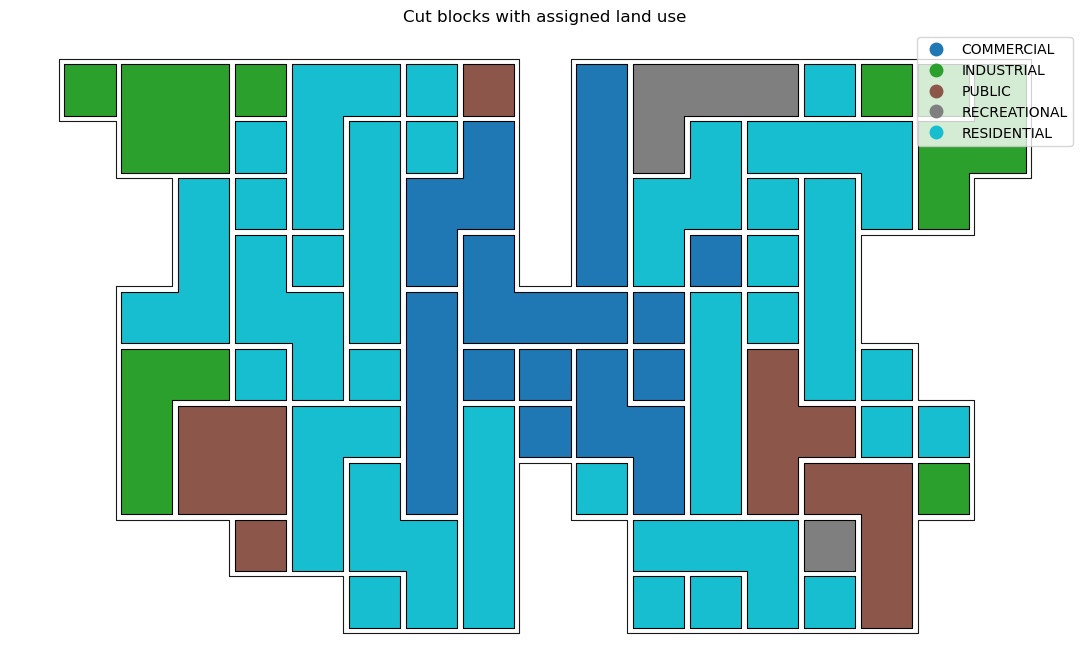

In [7]:
# Cut, label blocks and assign land use
blocks_path = output_shapefile
roads_path = os.path.join(output_folder,"road_polygons.shp")
output_path = os.path.join(output_folder,"City_1.shp")

blocks, road_network, crs = SewerTris.load_blocks_and_roads(blocks_path, roads_path)
blocks = SewerTris.cut_blocks(blocks, road_network)
blocks = SewerTris.assign_land_use_compact(blocks)
gdf = SewerTris.export_to_shapefile(blocks, crs, output_path)


# Read roads for plotting (optional but recommended)
roads_gdf = gpd.read_file(roads_path)
if roads_gdf.crs != gdf.crs:
    roads_gdf = roads_gdf.to_crs(gdf.crs)

# Plot
plots.plot_blocks_landuse(
    blocks_gdf=gdf,
    roads_gdf=roads_gdf,
    landuse_col="land_use",   # ← FIX
    title="Cut blocks with assigned land use",
    savepath=os.path.join(output_folder, "blocks_landuse.png")
)

✅ Extracted 134 manholes from road centerlines.
✅ Manholes exported to output_sewertris_1/manholes.shp

Path Statistics:
Head: MH128  →  Target: MH087
Segments: 24
Total length: 2500.0 m
Total drop: 8.73 m
Avg slope: 0.352%
⚠️ Some manholes could not be connected while preserving constraints.
✅ Generated 91 secondary pipes.
✅ Cleaned: 0 secondary pipes removed.
Main outlet ID: MH087
Total manholes: 134
Nodes already touched by main+secondary: 116
Manholes missing outlet pipe: 18
First 20 missing: ['MH007', 'MH010', 'MH024', 'MH035', 'MH042', 'MH059', 'MH064', 'MH079', 'MH084', 'MH085', 'MH094', 'MH095', 'MH109', 'MH111', 'MH114', 'MH124', 'MH127', 'MH129']
Duplicate sources: []
📊 Initial missing outlet pipes: 18
Iteration 1: start=MH035, status=committed, chain_len=1, remaining=17
Iteration 2: start=MH042, status=committed, chain_len=3, remaining=14
Iteration 3: start=MH064, status=committed, chain_len=2, remaining=12
Iteration 4: start=MH109, status=committed, chain_len=1, remaining=1

/Users/kevinblanco/Documents/Sewertris/Examples/../Functions/sewertris_fn_0_1.py:6175: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf.to_file(output_path)
/opt/anaconda3/envs/Hydro_process/lib/python3.10/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'downstream_m' to 'downstream'
  ogr_write(


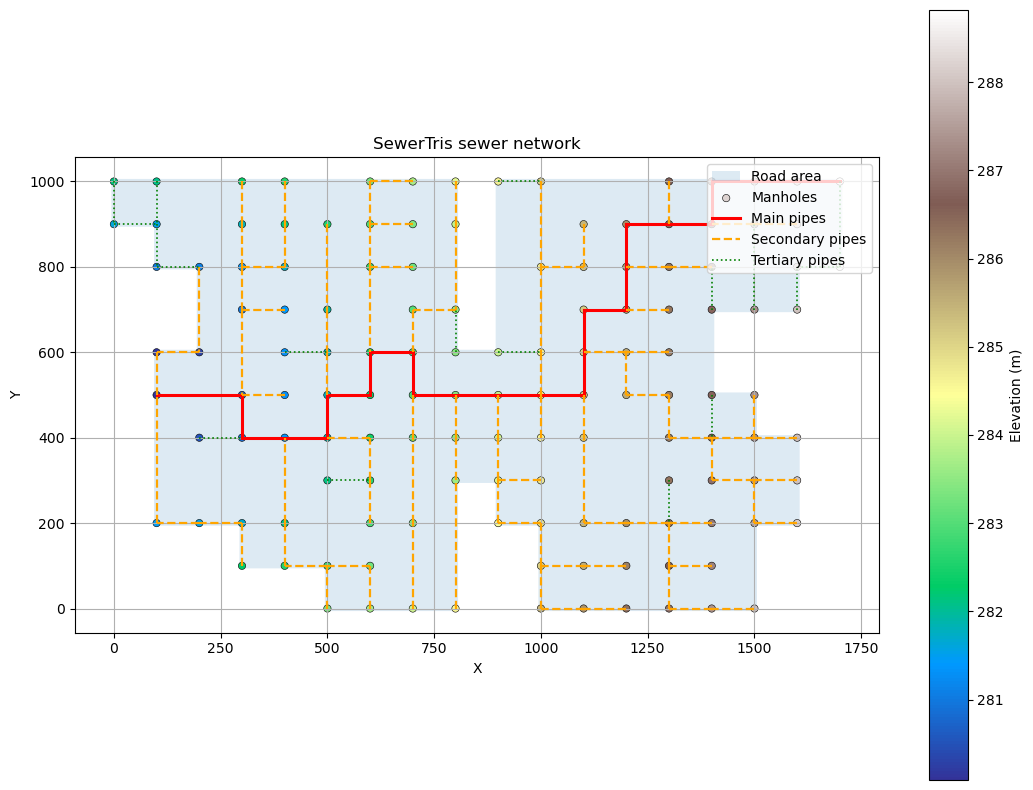

In [8]:
road_axes_path=os.path.join(output_folder,"road_centerlines.shp")
dem_path=os.path.join(output_folder,"generated_topography.tif")
manholes = SewerTris.extract_manholes_from_lines(road_axes_path, dem_path)
SewerTris.export_manholes_to_shapefile(manholes, os.path.join(output_folder,"manholes.shp"), crs=gpd.read_file(road_axes_path).crs)

# Generate main sewer path

road_buffer=road_lines.buffer(road_width * 0.6)

segments, path_info, graph_data = SewerTris.generate_main_sewer_path_optimized(
    manholes=manholes,
    road_buffer=road_buffer,
    block_size=min_width*2,
    slope_tolerance=-0.01,
    min_pipe_length=5.0,
    prefer_slope=0.5,
    return_graph_data=True,
)

# Generate secondary sewer pipes

main_path = path_info["segments"]

secondary_pipes, secondary_attrs = SewerTris.generate_secondary_pipes_optimized(
    manholes=manholes,
    main_path=main_path,
    road_buffer=road_lines.buffer(road_width * 0.6),
    block_size=min_width * 2,
    slope_tolerance=0.00,
    prefer_slope=0.5,
    return_attrs=True,
)

secondary_pipes_clean = SewerTris.remove_secondary_pipes_overlapping_main_optimized(
    manholes=manholes,
    secondary_pipes=secondary_pipes,
    main_pipes=main_path
)

# Check Sewer Network Status

network_status = SewerTris.build_current_network_status(
    manholes=manholes,
    main_path=main_path,
    secondary_pipes=secondary_pipes_clean,
)

print("Main outlet ID:", network_status["main_outlet_id"])
print("Total manholes:", len(network_status["all_ids"]))
print("Nodes already touched by main+secondary:", len(network_status["nodes_in_network"]))
print("Manholes missing outlet pipe:", len(network_status["missing_outlet_ids"]))
print("First 20 missing:", network_status["missing_outlet_ids"][:20])
print("Duplicate sources:", network_status["duplicate_sources"][:20])

# Generate tertiary pipes

tertiary_pipes, tertiary_unconnected, tertiary_attrs = SewerTris.generate_tertiary_pipes_backtracking_stop_at_each_manhole(
    manholes=manholes,
    main_path=main_path,
    secondary_pipes=secondary_pipes_clean,
    road_buffer=road_lines.buffer(road_width * 0.6),
    city_boundary=os.path.join(output_folder, "road_outer_shell.shp"),
    block_size=min_width * 10,
    neighbor_radius_factor=1.5,
    min_pipe_length=1e-3,
    point_on_line_tol=0.01,
    return_attrs=True,
    max_search_depth=300,
)

# Export to shapefile

main_attrs = SewerTris.build_main_attrs_from_path_info(path_info)

gdf_pipes = SewerTris.export_pipes_to_shapefile_2(
    pipes_main=main_path,
    pipes_sec=secondary_pipes_clean,
    pipes_ter=tertiary_pipes,
    manholes=manholes,
    output_path=os.path.join(output_folder, "sewer_pipes.shp"),
    crs=crs,
    main_attrs=main_attrs,
    secondary_attrs=secondary_attrs,
    tertiary_attrs=tertiary_attrs,
)

print("✓ Sewer network generation complete.")

plots.plot_sewer_network_all(
    manholes=manholes,
    main_pipes=main_path,
    secondary_pipes=secondary_pipes_clean,
    tertiary_pipes=tertiary_pipes,
    unresolved=tertiary_unconnected,
    road_buffer=road_buffer,  # from unary_union(roads_gdf.geometry)
    title="SewerTris sewer network"
)

Modifying topography to follow sewer network...
⚠️ Raster check: 72 pipes have a local slope < Smin (e.g., idx=125, slope=-0.000357).
Wrote: output_sewertris_1/generated_topography.tif
Updated elevations for 134/134 manholes. Wrote: output_sewertris_1/manholes.shp


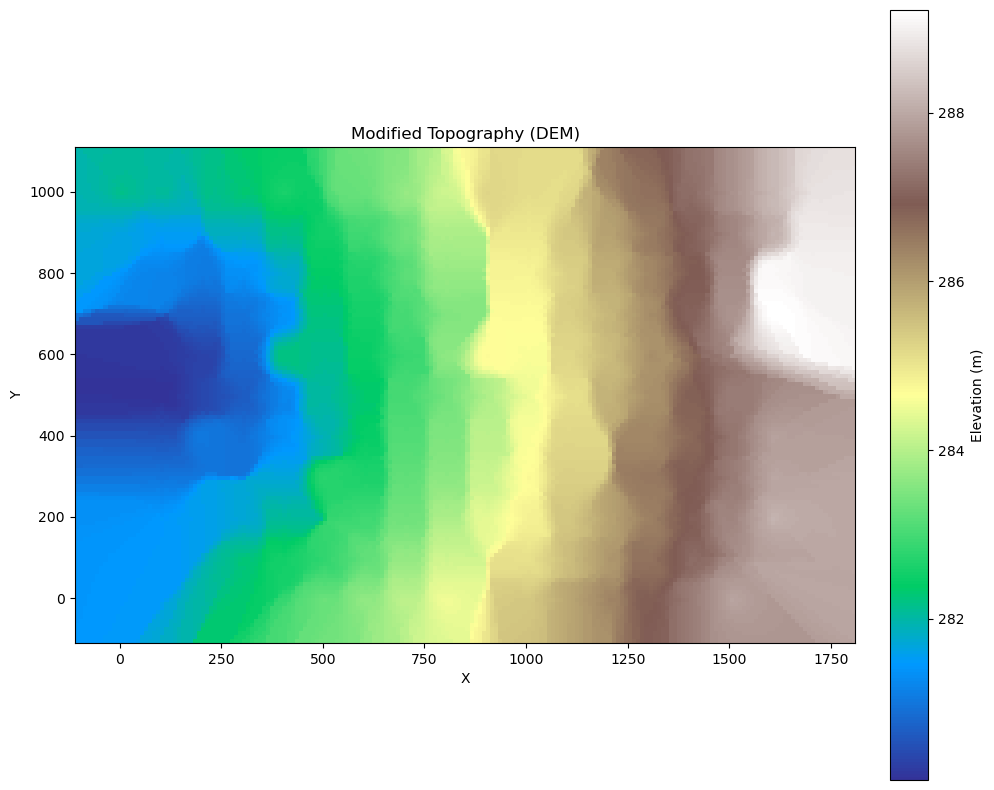

In [9]:
# Modifying topography
print("Modifying topography to follow sewer network...")

# Define paths and parameters
dem_path = os.path.join(output_folder, "generated_topography.tif")
sewer_path = os.path.join(output_folder, "sewer_pipes.shp")
manholes_path = os.path.join(output_folder, "manholes.shp")
output_path = os.path.join(output_folder, "generated_topography.tif")

out_path = SewerTris.build_dem_with_guaranteed_positive_slopes_idw(
    dem_path=dem_path,
    pipes_path=sewer_path,
    manholes_path=manholes_path,
    output_path=output_path,
    upstream_field="upstream_m",
    downstream_field="downstream",
    manhole_id_field="id",
    manhole_elev_field="elevation",
    type_field="type",
    tier_order=("main","secondary","tertiary"),
    Smin=0.001,                                 # 0.3% min slope
    densify_step_m=None,                        # default ≈ 2 pixels
    along_pipe_weight=2,                        # small bias toward pipes
    idw_power=2.0, idw_k=12, idw_tile=1024,
    centerline_writeback=True,                  # guarantees pixel-level monotone on centerlines
    verify_on_raster=True
)
print("Wrote:", out_path)

# Update manhole elevations in the shapefile
SewerTris.update_manhole_elevations_from_dem(
    dem_path=out_path,
    manholes_path=manholes_path,
    output_path=None,    # None + overwrite=True -> overwrite original file
    overwrite=True,
    sampling="nearest",
)

plots.plot_dem_tif(output_path, title="Modified Topography (DEM)", hillshade=False)


/Users/kevinblanco/Documents/Sewertris/Examples/../Functions/sewertris_fn_0_1.py:3101: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  output.to_file(output_path)
/opt/anaconda3/envs/Hydro_process/lib/python3.10/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'base_flow_lps' to 'base_flow_'
  ogr_write(
/Users/kevinblanco/Documents/Sewertris/Examples/../Functions/sewertris_fn_0_1.py:6328: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  pipes.to_file(output_path)
/opt/anaconda3/envs/Hydro_process/lib/python3.10/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'own_flow_lps' to 'own_flow_l'
  ogr_write(
/opt/anaconda3/envs/Hydro_process/lib/python3.10/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'cumulative_flow_lps' to 'cumulative'
  ogr_write(
/var/folders/2w/7qxwf1vx23j4x3f

✅ Sub-catchments saved to: output_sewertris_1/sewer_subcatchments.shp
✅ Updated pipe file saved: output_sewertris_1/sewer_pipes.shp
✅ Peak flows added using BC method.
✅ Pipe slopes assigned and saved to: output_sewertris_1/sewer_pipes.shp
✅ Materials and diameters assigned and saved to: output_sewertris_1/sewer_pipes.shp
✅ Invert elevations assigned and saved to: output_sewertris_1/sewer_pipes.shp
✅ Pipes saved to: output_sewertris_1/sewer_pipes.shp
✅ Manholes saved to: output_sewertris_1/manholes.shp


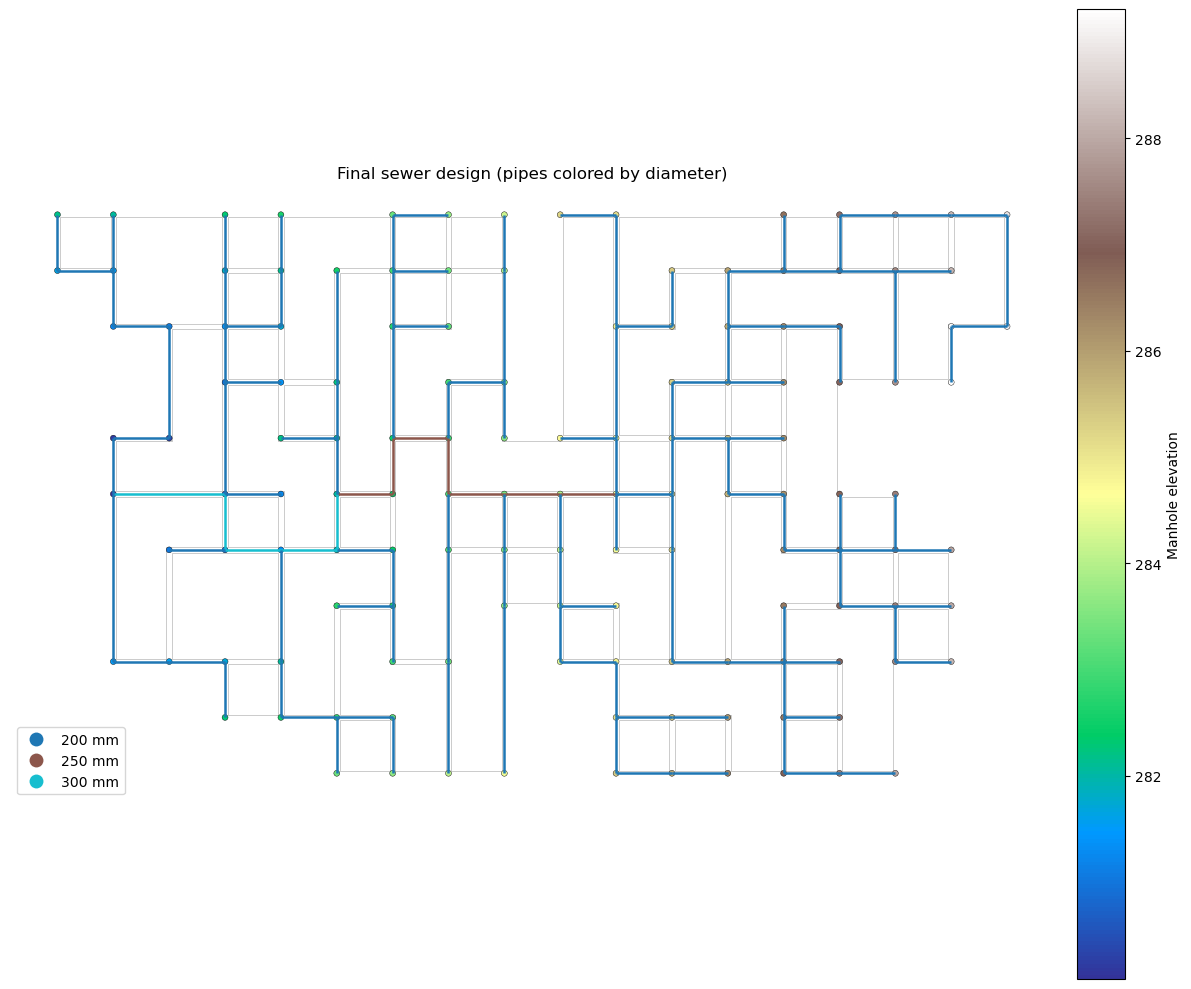

In [10]:
blocks_path = os.path.join(output_folder, "City_1.shp")
manholes_path = os.path.join(output_folder, "manholes.shp")
pipes_path = os.path.join(output_folder, "sewer_pipes.shp")
topography_path = os.path.join(output_folder, "generated_topography.tif")

#🚰 LAND_USE_INFO
# For each land use category:
# - 'density' is in people per hectare [people/ha]
# - 'demand' is in liters per person per day [L/person/day]

LAND_USE_INFO = {
    'RESIDENTIAL': {
        'density': 60,     # [people/ha]
        'demand': 100       # [L/person/day]
    },
    'COMMERCIAL': {
        'density': 50,      # [people/ha] or equivalent occupancy
        'demand': 60       # [L/person/day]
    },
    'INDUSTRIAL': {
        'density': 25,      # [people/ha] or equivalent worker density
        'demand': 150       # [L/person/day]
    },
    'PUBLIC': {
        'density': 20,      # [people/ha]
        'demand': 100       # [L/person/day]
    },
    'RECREATIONAL': {
        'density': 10,      # [people/ha]
        'demand': 40        # [L/person/day]
    }
}

# Afferent areas and baseflow

SewerTris.delineate_afferent_areas_and_baseflow(
    blocks_path=blocks_path,
    pipes_path=pipes_path,
    manholes_path=manholes_path,
    topo_path=topography_path,
    output_path=os.path.join(output_folder, "sewer_subcatchments.shp"),
    land_use_info=LAND_USE_INFO
)

subcatchments_path = os.path.join(output_folder, "sewer_subcatchments.shp")

# Assign flow to pipes
SewerTris.assign_flow_to_pipes_fast(
    pipes_path=pipes_path,
    subcatchments_path=subcatchments_path,
    output_path=os.path.join(output_folder, "sewer_pipes.shp")
)

# Peak flow

pipes = gpd.read_file(os.path.join(output_folder, "sewer_pipes.shp"))

# Apply BC peaking factor
peak_flow, pf = SewerTris.british_columbia_peaking_factor(pipes["cumulative"])
pipes["peaking_factor_bc"] = pf
pipes["peak_flow_lps_bc"] = peak_flow

# Save
pipes.to_file(os.path.join(output_folder, "sewer_pipes.shp"))
print("✅ Peak flows added using BC method.")

# GWI

pipes_path = os.path.join(output_folder, "sewer_pipes.shp")

SewerTris.compute_gwi_cumulative(
    pipes_path=pipes_path,
    gwi_factor_ls_per_m=0.0002,            # l/s per meter
    out_path=os.path.join(output_folder,"sewer_pipes.shp"),         # or None if you don't want to write
    id_field="pipe_id",
    up_field="upstream_m",
    down_field="downstream",
    length_field=None,                     # if you already have meters in a column, put its name here
    target_crs_m="EPSG:3857"          # UTM zone for accurate length calculations
    )

# RDII

pipes_path = os.path.join(output_folder, "sewer_pipes.shp")

SewerTris.compute_rdii_and_accumulate(
    pipes_path=pipes_path,
    subcatch_path=subcatchments_path,
    rdii_factor_ls_per_m2=0.00002,       # L/s per m² (example)
    pipe_id_field="pipe_id",
    up_field="upstream_m",
    down_field="downstream",
    sub_pipe_field="pipe_id",            # subcatchments' field pointing to receiving pipe
    # If your subcatchments are in degrees, choose a projected CRS in meters:
    target_crs_m="EPSG:3857",
    out_pipes=os.path.join(output_folder,"sewer_pipes.shp"),
    out_subcatch=os.path.join(output_folder,"sewer_subcatchments.shp"),
)

# Predising flow

pipes_path = os.path.join(output_folder,"sewer_pipes.shp")

SewerTris.add_predesign_flow(
    pipes_path=pipes_path,
    out_path=os.path.join(output_folder,"sewer_pipes.shp")
)

# Pipe slopes

pipes_path = os.path.join(output_folder, "sewer_pipes.shp")

SewerTris.assign_pipe_slopes(
    pipes_path=pipes_path,
    manholes_path=manholes_path,
    output_path=os.path.join(output_folder, "sewer_pipes.shp"),
    minimum_slope=0.005  # Can be adjusted per local design standards
)

# Pipe Diameter and material

pipes_path = os.path.join(output_folder, "sewer_pipes.shp")

SewerTris.assign_material_diameter_to_pipes(
    pipes_path=pipes_path,
    output_path=os.path.join(output_folder, "sewer_pipes.shp"),
    material_fractions={"PVC": 0.6, "CONCRETE": 0.3, "HDPE": 0.1},
    n_by_material={"PVC": 0.011, "CONCRETE": 0.013, "HDPE": 0.012},
    standard_diameters_mm=[200, 250, 300, 350, 400, 450, 500, 600, 700, 800, 900, 1000, 1100, 1200, 1300, 1400, 1500, 1600, 1700, 1800, 1900, 2000],
    minimum_diameter_mm=200
)

# Pipe Invert Elevations

pipes_path = os.path.join(output_folder, "sewer_pipes.shp")

SewerTris.assign_invert_elevations(
    pipes_path=pipes_path,
    output_path=os.path.join(output_folder, "sewer_pipes.shp"),
    min_cover=1.4,
    min_slope=0.005,
    manhole_drop=0.05
)

# Preprocess pipes and manholes

pipes_path = os.path.join(output_folder, "sewer_pipes.shp")

SewerTris.preprocess_pipes_and_manholes(
    pipes_path=pipes_path,
    manholes_path=manholes_path,
    output_pipes_path=os.path.join(output_folder, "sewer_pipes.shp"),
    output_manholes_path=os.path.join(output_folder, "manholes.shp")
)

final_pipes = os.path.join(output_folder, "sewer_pipes.shp")
final_mhs   = os.path.join(output_folder, "manholes.shp")
    
plots.plot_final_design_color_by_diameter(
    pipes_path=final_pipes,
    manholes_path=final_mhs,
    blocks_path=blocks_path,  # optional
    diameter_field="diameter_m",   # change if your field name differs
    manhole_color_field="elevation",  # optional; change if needed
    linewidth=1.8,
)

## 3. Export to EPA-SWMM

In [11]:
# Export to SWMM INP format

pipes_path = os.path.join(output_folder, "sewer_pipes.shp")
manholes_path = os.path.join(output_folder, "manholes.shp")
options = {
    "FLOW_UNITS": "LPS",
    "INFILTRATION": "CURVE_NUMBER",
    "FLOW_ROUTING": "KINWAVE",
    "LINK_OFFSETS": "DEPTH",
    "MIN_SLOPE": "0",
    "ALLOW_PONDING": "NO",
    "SKIP_STEADY_STATE": "NO",
    "START_DATE": "01/01/2025",
    "START_TIME": "00:00:00",
    "REPORT_START_DATE": "01/01/2025",
    "REPORT_START_TIME": "00:00:00",
    "END_DATE": "02/01/2025",
    "END_TIME": "00:00:00",
    "SWEEP_START": "01/01",
    "SWEEP_END": "12/31",
    "DRY_DAYS": "0",
    "REPORT_STEP": "00:15:00",
    "WET_STEP": "00:05:00",
    "DRY_STEP": "01:00:00",
    "ROUTING_STEP": "0:00:30",
    "RULE_STEP": "00:00:00",
    "INERTIAL_DAMPING": "PARTIAL",
    "NORMAL_FLOW_LIMITED": "BOTH",
    "FORCE_MAIN_EQUATION": "D-W",
    "VARIABLE_STEP": "0.75",
    "LENGTHENING_STEP": "0",
    "MIN_SURFAREA": "1.167",
    "MAX_TRIALS": "8",
    "HEAD_TOLERANCE": "0.0015",
    "SYS_FLOW_TOL": "5",
    "LAT_FLOW_TOL": "5",
    "MINIMUM_STEP": "0.5",
    "THREADS": "1"
}

swmm.export_swmm_inp(
    pipes_path=pipes_path,
    manholes_path=manholes_path,
    output_path=os.path.join(output_folder, "sewer_model.inp"),
    options_dict=options
)

✅ SWMM .inp file written to: output_sewertris_1/sewer_model.inp


/Users/kevinblanco/Documents/Sewertris/Examples/../Functions/sewertris_swmm_0_1.py:148: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  manholes["invert_elev"].fillna(manholes["elevation"] - 1.0, inplace=True)



## 4. Define Input Flows

✅ Updated [DWF] with patterns "1" "2" "3" "4"
✅ Rewrote [PATTERNS] with HOURLY, DAILY, MONTHLY, WEEKEND
   Output saved to: output_sewertris_1/sewer_model.inp
✅ SWMM INP file with DWF patterns created.


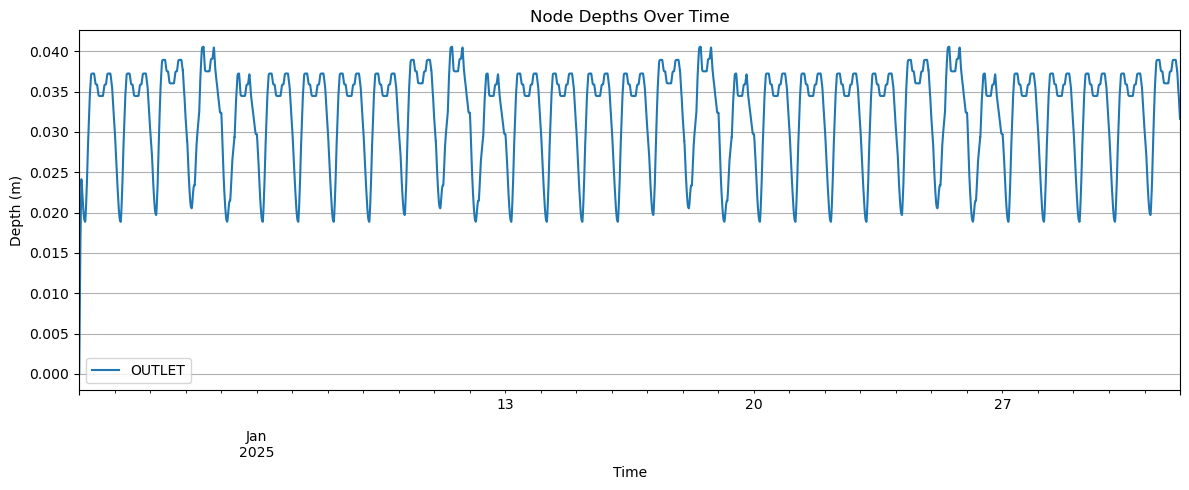

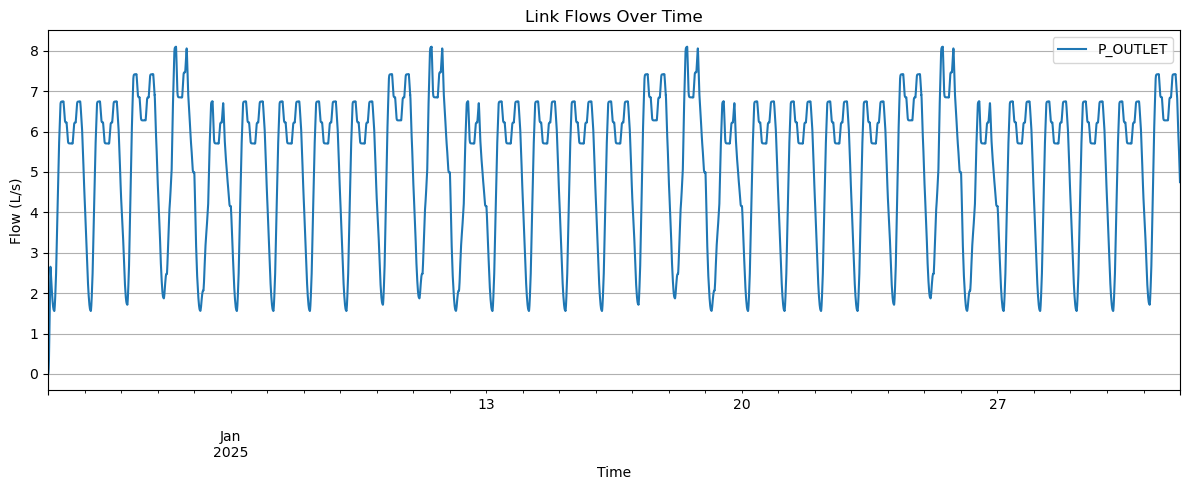

In [12]:
# BWF Patterns

SWMM_INPUT_FILE = os.path.join(output_folder, "sewer_model.inp")

# Define BWF patterns

hourly = [
    0.5631, 0.4163, 0.3181, 0.3178, 0.4838, 0.8014,
    1.1337, 1.3239, 1.3321, 1.2512, 1.1900, 1.1703,
    1.1489, 1.1063, 1.0762, 1.0943, 1.1545, 1.2270,
    1.2931, 1.3362, 1.3175, 1.1978, 0.9890, 0.7576
]

daily_vals = [1.0, 1.0, 1.0, 1.0, 1.0, 1.1, 1.2]  # Mon..Sun

monthly_vals = [  # Jan..Dec
    0.90, 0.95, 1.00, 1.05,
    1.10, 1.10, 1.05, 1.00,
    0.95, 0.90, 0.90, 0.90,
]

fairfax_weekend = [
    0.5631, 0.4163, 0.3181, 0.3178, 0.3568, 0.4068,
    0.6068, 0.7068, 0.8014, 1.1337, 1.3239, 1.3321,
    1.1489, 1.1063, 1.0762, 1.0943, 1.1545, 1.2270,
    1.2931, 1.1362, 1.0175, 0.8978, 0.8090, 0.7576
]

# Assign DWF patterns to the SWMM model
SewerTris.assign_all_dwf_patterns(
    inp_path=SWMM_INPUT_FILE,
    output_path=os.path.join(output_folder, "sewer_model.inp"),
    hourly_id="1",
    hourly_values=hourly,
    daily_id="2",
    daily_values=daily_vals,
    monthly_id="3",
    monthly_values=monthly_vals,
    weekend_id="4",
    weekend_values=fairfax_weekend
)

print("✅ SWMM INP file with DWF patterns created.")

nodes_to_monitor = ["OUTLET"]
links_to_monitor = ["P_OUTLET"]

depths_df, flows_df = swmm.run_swmm_and_plot(os.path.join(output_folder, "sewer_model.inp"), monitored_nodes=nodes_to_monitor, monitored_links=links_to_monitor)


✅ INFLOWS section created using coefficient 0.0001. File saved to: output_sewertris_1/sewer_model.inp


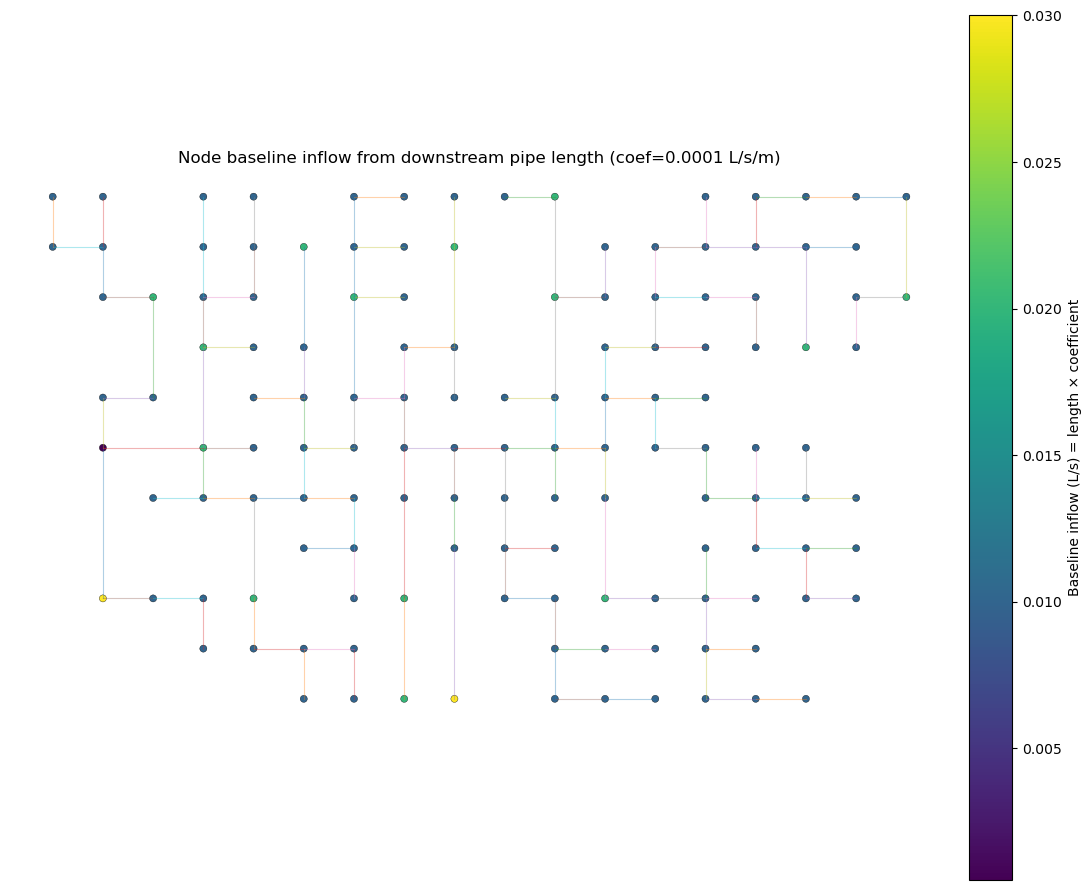

Nodes plotted: 134
Inflow range: 0.0005 to 0.0300 L/s


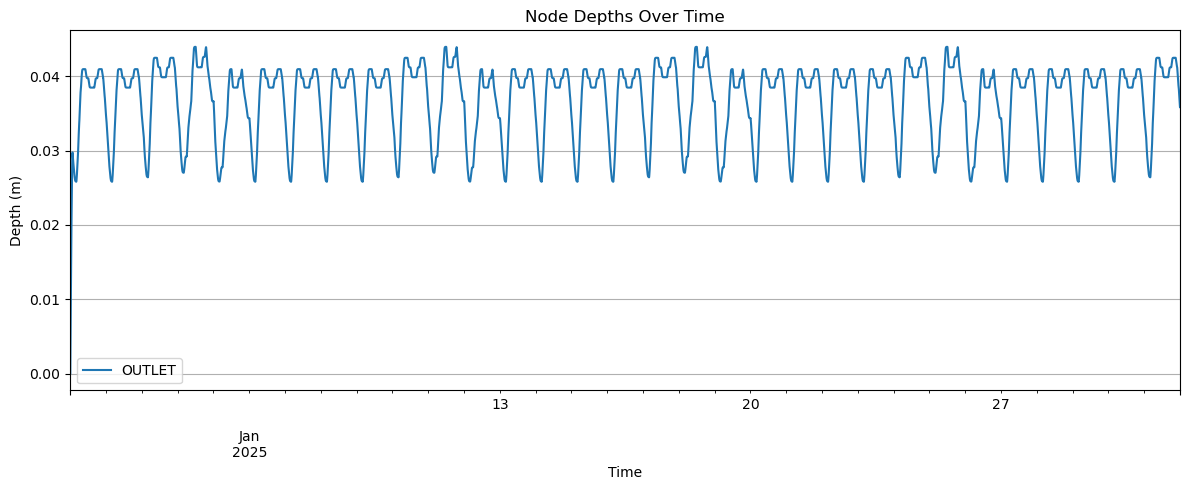

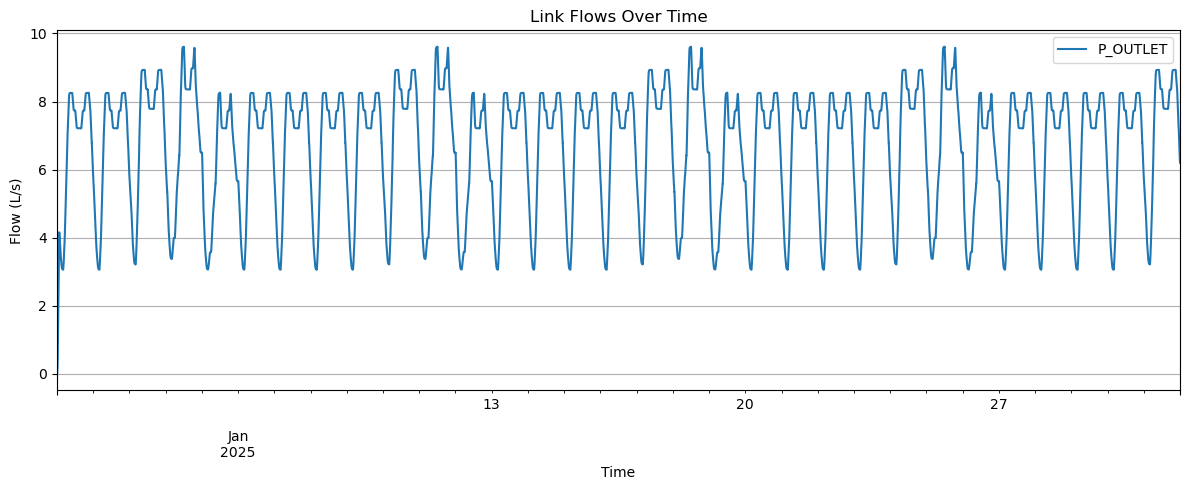

In [13]:
# GWI

inp_file = os.path.join(output_folder, "sewer_model.inp")

swmm.assign_inflow_from_pipe_length(
    inp_path=inp_file,
    output_path=os.path.join(output_folder, "sewer_model.inp"),
    coefficient=0.0001  # LPS per meter
)

inp_file = os.path.join(output_folder, "sewer_model.inp")
plots.plot_inflow_from_pipe_length(
    inp_path=inp_file,
    coefficient=0.0001,
)

nodes_to_monitor = ["OUTLET"]
links_to_monitor = ["P_OUTLET"]

depths_df, flows_df = swmm.run_swmm_and_plot(os.path.join(output_folder, "sewer_model.inp"), monitored_nodes=nodes_to_monitor, monitored_links=links_to_monitor)


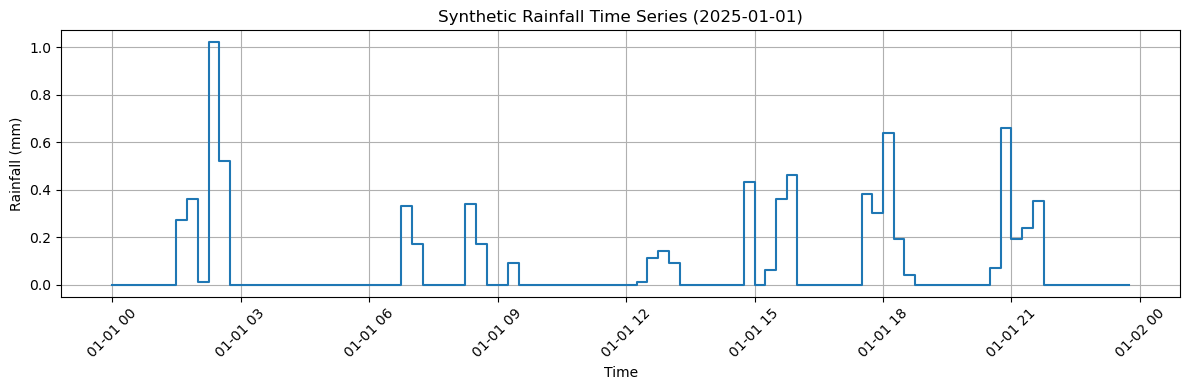

✅ SWMM .inp file updated with subcatchments and saved to: output_sewertris_1/sewer_model.inp


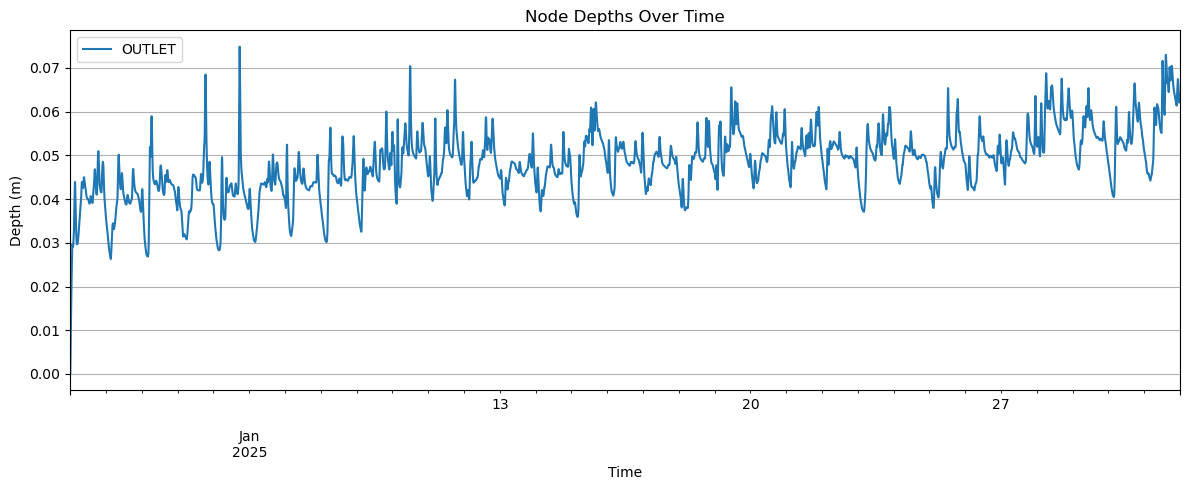

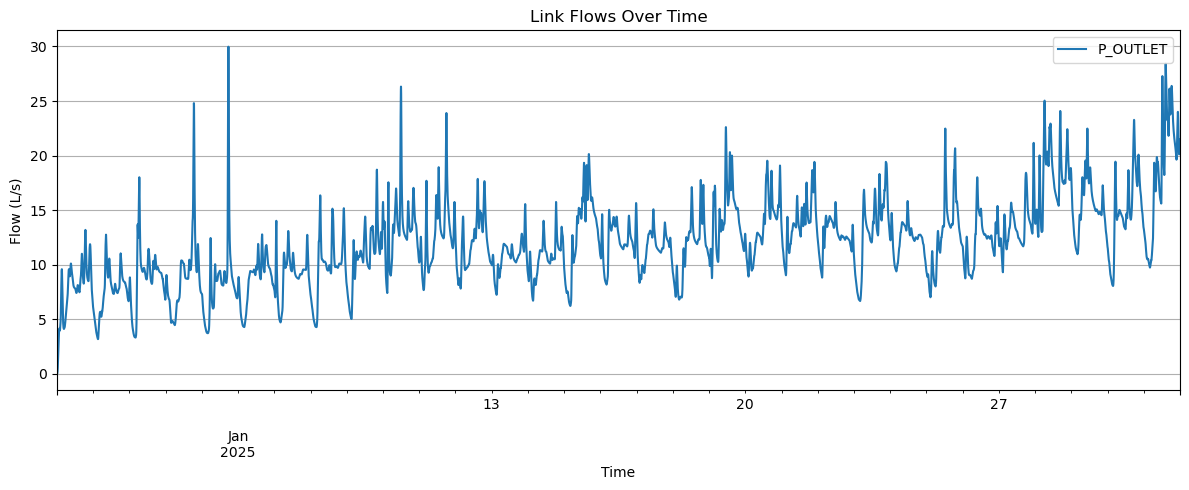

In [14]:
# RDII

inp_file = os.path.join(output_folder, "sewer_model.inp")

# Time Series Generation
rainfall_data = SewerTris.generate_clustered_rainfall_timeseries(
    start_date="2025-01-01 00:00",
    end_date="2025-02-01 00:00",
    timestep_minutes=15,
    avg_annual_precip_mm=1200,
    wet_season_months=[4, 5, 6, 9, 10, 11],
    dry_wet_ratio=0.2,
    storm_prob=0.1,  # Probability of storm initiation per timestep
    storm_duration_range=(1, 6),  # Storm duration in number of timesteps (e.g., 1–5 hours)
    random_seed=42,
    preview_date="2025-01-01"
)

subcatchments_path = os.path.join(output_folder, "sewer_subcatchments.shp")

swmm.add_subcatchment_data_to_inp(
    inp_path=inp_file,
    output_path=os.path.join(output_folder, "sewer_model.inp"),
    subcatchments_path=subcatchments_path,
    raingage_id="1",
    raingage_coords=(500, 500),
    timeseries=rainfall_data,
    n_imperv=0.011, n_perv=0.15,
    s_imperv=0.0, s_perv=0.0,
    pct_zero=0, route_to="OUTLET", pct_routed="",
    infiltration_params=(50, 0.5, 7, "", ""),
    imperv_pct=5, width=100, slope=0.005, curblen=0
)

nodes_to_monitor = ["OUTLET"]
links_to_monitor = ["P_OUTLET"]

depths_df, flows_df = swmm.run_swmm_and_plot(os.path.join(output_folder, "sewer_model.inp"), monitored_nodes=nodes_to_monitor, monitored_links=links_to_monitor)


## 5. Run Model with WQ

✅ Tagged inp written (uses CONCEN) -> output_sewertris_1/sewer_model.inp


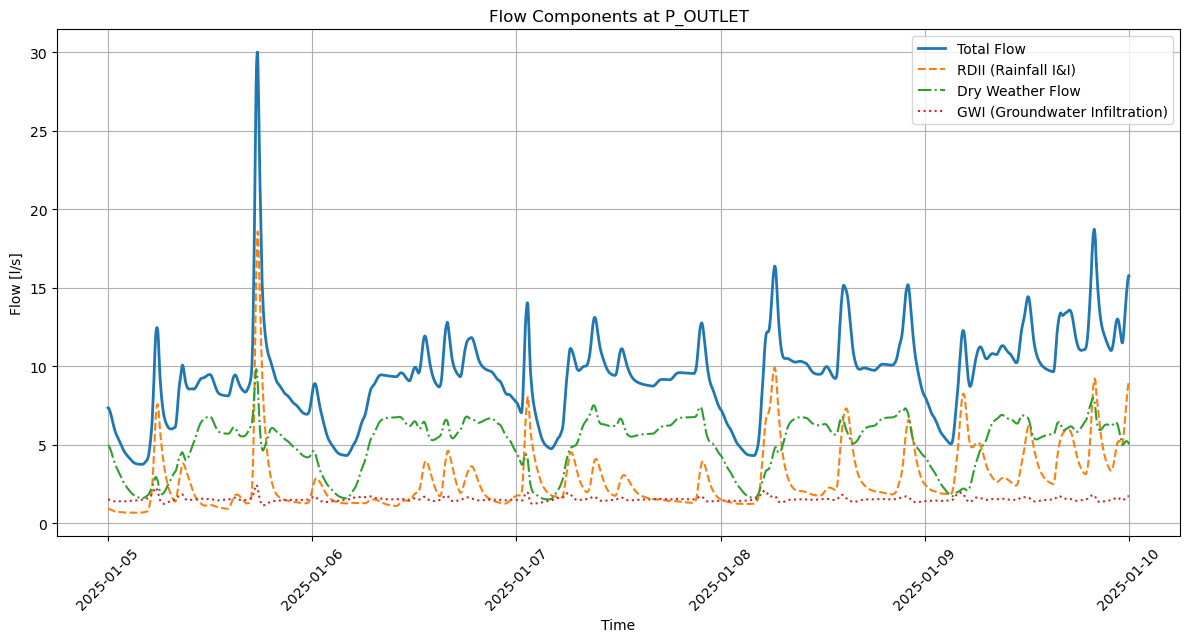

✅ Saved as flows.nc


In [15]:
inp_file = os.path.join(output_folder, "sewer_model.inp")

swmm.auto_add_pollutants_to_inp_fixed(
    inp_path=inp_file,
    output_path=os.path.join(output_folder, "sewer_model.inp")
)

inp_path = os.path.join(output_folder, "sewer_model.inp")

df = swmm.get_flow_components_from_node_pyswmm(
    inp_path=inp_path,
    link_id="P_OUTLET"
)

plots.plot_flow_components_v2(
    df,
    start="2025-01-05 00:00:00",
    end="2025-01-10 00:00:00"
)

# Set Datetime as index
df = df.set_index("Datetime")

# Convert DataFrame → Xarray Dataset
ds = df.to_xarray()

# Save to NetCDF
ds.to_netcdf(os.path.join(output_folder, "flows.nc"))
print("✅ Saved as flows.nc")